In [1]:
import matplotlib.pyplot as plt
import io
import base64
from IPython.display import display, HTML

# Добавляем CSS для глобального применения прокрутки к графикам
display(HTML("""
    <style>
        .scrollable-output {
            max-height: 300px;
            overflow-y: auto;
            border: 1px solid #ddd;
            padding: 5px;
        }
    </style>
"""))

def scrollable_plot(fig, height=400):
    """Выводит matplotlib figure в прокручиваемом контейнере"""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches='tight')
    buf.seek(0)
    img_base64 = base64.b64encode(buf.getvalue()).decode()
    
    html = f"""
    <div class="scrollable-output" style="max-height: {height}px;">
        <img src="data:image/png;base64,{img_base64}">
    </div>
    """
    plt.close(fig)  # Закрываем фигуру, чтобы избежать двойного вывода
    display(HTML(html))

# Пример использования
# fig, ax = plt.subplots(figsize=(10, 5))
# ax.plot(range(10), range(10))
# scrollable_plot(fig)


In [2]:
import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
%matplotlib inline
plt.rcParams["image.cmap"] = 'magma'
import seaborn as sns
from tqdm.notebook import tqdm
from tabulate import tabulate

from sklearn.metrics.pairwise import cosine_similarity

from damo.config.base import parse_config
from tools.demo import Infer

from my_help_functions.hooks import register_conv_bn_hooks
from my_help_functions.cosine_matrix import get_positions_of_classes_on_flattened_image, get_positions_of_classes_on_flattened_image_for_collage


In [3]:
config = parse_config('./configs/damoyolo_tinynasL20_T.py')

infer_engine = Infer(config, device='cuda',
    ckpt='./weights/damoyolo_tiny.pth')

model = infer_engine.model.eval()

Inference with torch engine!


In [ ]:
# for name, layer in list(model.named_modules()):
#     print(name, layer)

 Detector(
  (backbone): TinyNAS(
    (block_list): ModuleList(
      (0): Focus(
        (conv): ConvBNAct(
          (conv): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn): BatchNorm2d(24, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): ReLU(inplace=True)
        )
      )
      (1): SuperResStem(
        (act): ReLU(inplace=True)
        (block_list): ModuleList(
          (0): ResConvBlock(
            (conv1): ConvKXBN(
              (conv1): Conv2d(24, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn1): BatchNorm2d(24, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
            )
            (conv2): RepConv(
              (nonlinearity): Identity()
              (rbr_reparam): Conv2d(24, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
            )
            (activation_function): ReLU(inplace=True)
          )
          (1): ResConvBlock(
            (co

In [4]:
savefig = True

idx = 5
path = f'./collage/gray_collage_background_centroid_{idx}.jpg'

In [5]:
bns, convs = register_conv_bn_hooks(model)

isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance


In [6]:
origin_image = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
image, origin_shape = infer_engine.preprocess(origin_image)
output = model(image)

add conv backbone.block_list.0.conv.conv
add bn backbone.block_list.0.conv.bn
add conv backbone.block_list.1.block_list.0.conv1.conv1
add bn backbone.block_list.1.block_list.0.conv1.bn1
add conv backbone.block_list.1.block_list.1.conv1.conv1
add bn backbone.block_list.1.block_list.1.conv1.bn1
add conv backbone.block_list.2.block_list.0.conv1.conv1
add bn backbone.block_list.2.block_list.0.conv1.bn1
add conv backbone.block_list.2.block_list.1.conv1.conv1
add bn backbone.block_list.2.block_list.1.conv1.bn1
add conv backbone.block_list.3.block_list.0.conv1.conv1
add bn backbone.block_list.3.block_list.0.conv1.bn1
add conv backbone.block_list.3.block_list.1.conv1.conv1
add bn backbone.block_list.3.block_list.1.conv1.bn1
add conv backbone.block_list.4.block_list.0.conv1.conv1
add bn backbone.block_list.4.block_list.0.conv1.bn1
add conv backbone.block_list.4.block_list.1.conv1.conv1
add bn backbone.block_list.4.block_list.1.conv1.bn1
add conv backbone.block_list.5.block_list.0.conv1.conv1
ad

In [8]:
len(convs)

47

In [9]:
before_conv = np.array([convs[i][2].detach().cpu() for i in range(len(bns))])
after_conv = np.array([convs[i][2].detach().cpu() for i in range(len(bns))])

c:\Users\asche\anaconda3\envs\DAMO-YOLO\lib\site-packages\ipykernel_launcher.py:1: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  """Entry point for launching an IPython kernel.
c:\Users\asche\anaconda3\envs\DAMO-YOLO\lib\site-packages\ipykernel_launcher.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  """Entry point for launching an IPython kernel.
c:\Users\asche

In [10]:
before_conv = np.array([convs[i][2].detach().cpu() for i in range(len(bns))])
after_conv = np.array([convs[i][2].detach().cpu() for i in range(len(bns))])

c:\Users\asche\anaconda3\envs\DAMO-YOLO\lib\site-packages\ipykernel_launcher.py:1: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  """Entry point for launching an IPython kernel.
c:\Users\asche\anaconda3\envs\DAMO-YOLO\lib\site-packages\ipykernel_launcher.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  """Entry point for launching an IPython kernel.
c:\Users\asche

In [11]:
before_conv[0].shape

torch.Size([12, 320, 320])

In [12]:
after_center = np.array([bns[i][2].detach().cpu() - bns[i][1].running_mean.view(-1, 1, 1).detach().cpu() for i in range(len(bns))])

c:\Users\asche\anaconda3\envs\DAMO-YOLO\lib\site-packages\ipykernel_launcher.py:1: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  """Entry point for launching an IPython kernel.
c:\Users\asche\anaconda3\envs\DAMO-YOLO\lib\site-packages\ipykernel_launcher.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  """Entry point for launching an IPython kernel.


In [13]:
for i in range(len(after_conv)):
    print(before_conv[i].shape, after_conv[i].shape, after_center[i].shape)

torch.Size([12, 320, 320]) torch.Size([12, 320, 320]) torch.Size([24, 320, 320])
torch.Size([24, 320, 320]) torch.Size([24, 320, 320]) torch.Size([24, 320, 320])
torch.Size([64, 160, 160]) torch.Size([64, 160, 160]) torch.Size([24, 160, 160])
torch.Size([64, 160, 160]) torch.Size([64, 160, 160]) torch.Size([64, 160, 160])
torch.Size([96, 80, 80]) torch.Size([96, 80, 80]) torch.Size([64, 80, 80])
torch.Size([96, 80, 80]) torch.Size([96, 80, 80]) torch.Size([96, 80, 80])
torch.Size([192, 40, 40]) torch.Size([192, 40, 40]) torch.Size([96, 40, 40])
torch.Size([192, 40, 40]) torch.Size([192, 40, 40]) torch.Size([152, 40, 40])
torch.Size([192, 40, 40]) torch.Size([192, 40, 40]) torch.Size([152, 40, 40])
torch.Size([192, 40, 40]) torch.Size([192, 40, 40]) torch.Size([192, 40, 40])
torch.Size([384, 20, 20]) torch.Size([384, 20, 20]) torch.Size([192, 20, 20])
torch.Size([768, 20, 20]) torch.Size([768, 20, 20]) torch.Size([384, 20, 20])
torch.Size([192, 40, 40]) torch.Size([192, 40, 40]) torch.S

In [14]:
import torch.nn.functional as F

def pairwise_cosine_similarity(x1, x2):
    x1 = F.normalize(x1, dim=0)
    x2 = F.normalize(x2, dim=0)
    return x1.T @ x2

In [15]:
inside = []
outside = []
back = []

# q = torch.Tensor([0.05, 0.25, 0.5, 0.75, 0.95])

for k in tqdm(range(2, len(after_center))):
# for k in range(2, 3):
    # positions, class_names = get_positions_of_classes_on_flattened_image_for_collage(idx, after_center[k].size()[1], "gray_", "background_centroid_")
    positions, class_names = get_positions_of_classes_on_flattened_image_for_collage(idx, after_center[k].size()[1], "gray_")

    # if before_conv[k].size()[1] != after_conv[k].size()[1]:
    #     # a = after_conv[k].copy()
    #     u = torch.nn.Upsample(scale_factor=2, mode='bilinear')
    #     a = u(after_conv[k].unsqueeze(0)).squeeze()
    #     matr1 = a.flatten(1, 2).detach()
    # else:
    #     matr1 = after_conv[k].flatten(1, 2).detach()
    # matr2 = before_conv[k].flatten(1, 2).detach()
    matr = after_center[k].flatten(1, 2).detach()

    # csm = pairwise_cosine_similarity(matr1, matr1) - pairwise_cosine_similarity(matr2, matr2) # torch.tensor
    csm = pairwise_cosine_similarity(matr, matr) # torch.tensor
    n = len(positions)

    mean_angle_change_w_others_list = []
    angle_change_w_self_list = []
    angle_change_w_back_list = []

    for i in range(n - 1):
    # Для 1 класса
    # for i in range(1):

        mean_angle_change_w_others = 0
        angle_change_w_self = 0
        angle_change_w_back = 0
        # mean_angle_change_w_others_list_inner = []
        # angle_change_w_self_list_inner = []
        # angle_change_w_back_list_inner = []
        
        for j in range(n):
            pos_i = torch.tensor(positions[i + 1], device=csm.device)
            pos_j = torch.tensor(positions[j + 1], device=csm.device)
            pair_matrix = torch.meshgrid(pos_i, pos_j)
            submatrix = csm[pair_matrix[0], pair_matrix[1]]

            mean = submatrix.mean()
            # quantiles = torch.quantile(submatrix.flatten(), q)
            
            if i == j:
                angle_change_w_self_list.append(mean)
                # angle_change_w_self_list_inner.append(quantiles)
                angle_change_w_self = mean
            elif j == (n - 1):
                angle_change_w_back_list.append(mean)
                # angle_change_w_back_list_inner.append(quantiles)
                angle_change_w_back = mean
            else:
                mean_angle_change_w_others += mean
                # mean_angle_change_w_others_list_inner.append(quantiles)
        
        mean_angle_change_w_others /= (n - 2)
        mean_angle_change_w_others_list.append(mean_angle_change_w_others)
        # angle_change_w_self_list.append(torch.stack(angle_change_w_self_list_inner).mean(dim=0))
        # angle_change_w_back_list.append(torch.stack(angle_change_w_back_list_inner).mean(dim=0))
        # mean_angle_change_w_others_list.append(torch.stack(mean_angle_change_w_others_list_inner).mean(dim=0))

    inside.append(torch.tensor(angle_change_w_self_list).mean())
    outside.append(torch.tensor(mean_angle_change_w_others_list).mean())
    back.append(torch.tensor(angle_change_w_back_list).mean())
    
    # inside.append(torch.stack(angle_change_w_self_list).mean(dim=0))
    # outside.append(torch.stack(mean_angle_change_w_others_list).mean(dim=0))
    # back.append(torch.stack(angle_change_w_back_list).mean(dim=0))


  0%|          | 0/45 [00:00<?, ?it/s]

loading annotations into memory...
Done (t=1.36s)
creating index...
index created!
loading annotations into memory...
Done (t=1.91s)
creating index...
index created!
loading annotations into memory...
Done (t=1.53s)
creating index...
index created!
loading annotations into memory...
Done (t=0.85s)
creating index...
index created!
loading annotations into memory...
Done (t=0.70s)
creating index...
index created!
loading annotations into memory...
Done (t=0.79s)
creating index...
index created!
loading annotations into memory...
Done (t=0.72s)
creating index...
index created!
loading annotations into memory...
Done (t=0.73s)
creating index...
index created!
loading annotations into memory...
Done (t=0.80s)
creating index...
index created!
loading annotations into memory...
Done (t=0.78s)
creating index...
index created!
loading annotations into memory...
Done (t=0.70s)
creating index...
index created!
loading annotations into memory...
Done (t=0.78s)
creating index...
index created!
load

In [47]:
inside, outside, back

([tensor([-0.8005, -0.3474,  0.2549,  0.6663,  0.8977]),
  tensor([-0.9560, -0.5545,  0.3821,  0.8872,  0.9844]),
  tensor([-0.3397, -0.0491,  0.1745,  0.4170,  0.7102]),
  tensor([-0.1698,  0.0826,  0.2538,  0.4180,  0.6395]),
  tensor([-0.4102,  0.0467,  0.3376,  0.6044,  0.8468]),
  tensor([-0.3011, -0.0869,  0.0845,  0.2655,  0.5224]),
  tensor([-0.2088,  0.0122,  0.1814,  0.3629,  0.6275]),
  tensor([-0.6360, -0.1454,  0.2624,  0.6223,  0.8853]),
  tensor([-0.3062, -0.0761,  0.1222,  0.3338,  0.6224]),
  tensor([-0.3495, -0.0578,  0.1581,  0.3643,  0.6407]),
  tensor([-0.6063, -0.1604,  0.2623,  0.5850,  0.8538]),
  tensor([-0.2615, -0.0534,  0.1086,  0.2817,  0.5272]),
  tensor([-0.2704,  0.0229,  0.1935,  0.3654,  0.6429]),
  tensor([-0.5668, -0.0828,  0.2703,  0.5543,  0.8299]),
  tensor([-0.2526, -0.0119,  0.1823,  0.3914,  0.7068]),
  tensor([-0.3784,  0.0356,  0.3172,  0.5317,  0.7634]),
  tensor([-0.5948, -0.1434,  0.4451,  0.7831,  0.9303]),
  tensor([-0.2182, -0.0576,  0.

In [ ]:
def scale(X, mini, maxi, range_=(-1, 1)):
    min_, max_ = range_
    X = np.array(X)
    X_std = (X - mini) / (maxi - mini)
    X_scaled = X_std * (max_ - min_) + min_
    return X_scaled

# a_min = min(np.min(inside), np.min(outside), np.min(back))
# a_max = max(np.max(inside), np.max(outside), np.max(back))
# inside_scaled = scale(inside, a_min, a_max)
# outside_scaled = scale(outside, a_min, a_max)
# back_scaled = scale(back, a_min, a_max)


In [16]:
inside_np = torch.stack(inside).cpu().numpy()  # (95, 5)
outside_np = torch.stack(outside).cpu().numpy()  # (95, 5)
back_np = torch.stack(back).cpu().numpy()  # (95, 5)

In [21]:
bns_fwd_names = [name for name, _, _, _ in bns]
len(bns_fwd_names)

47

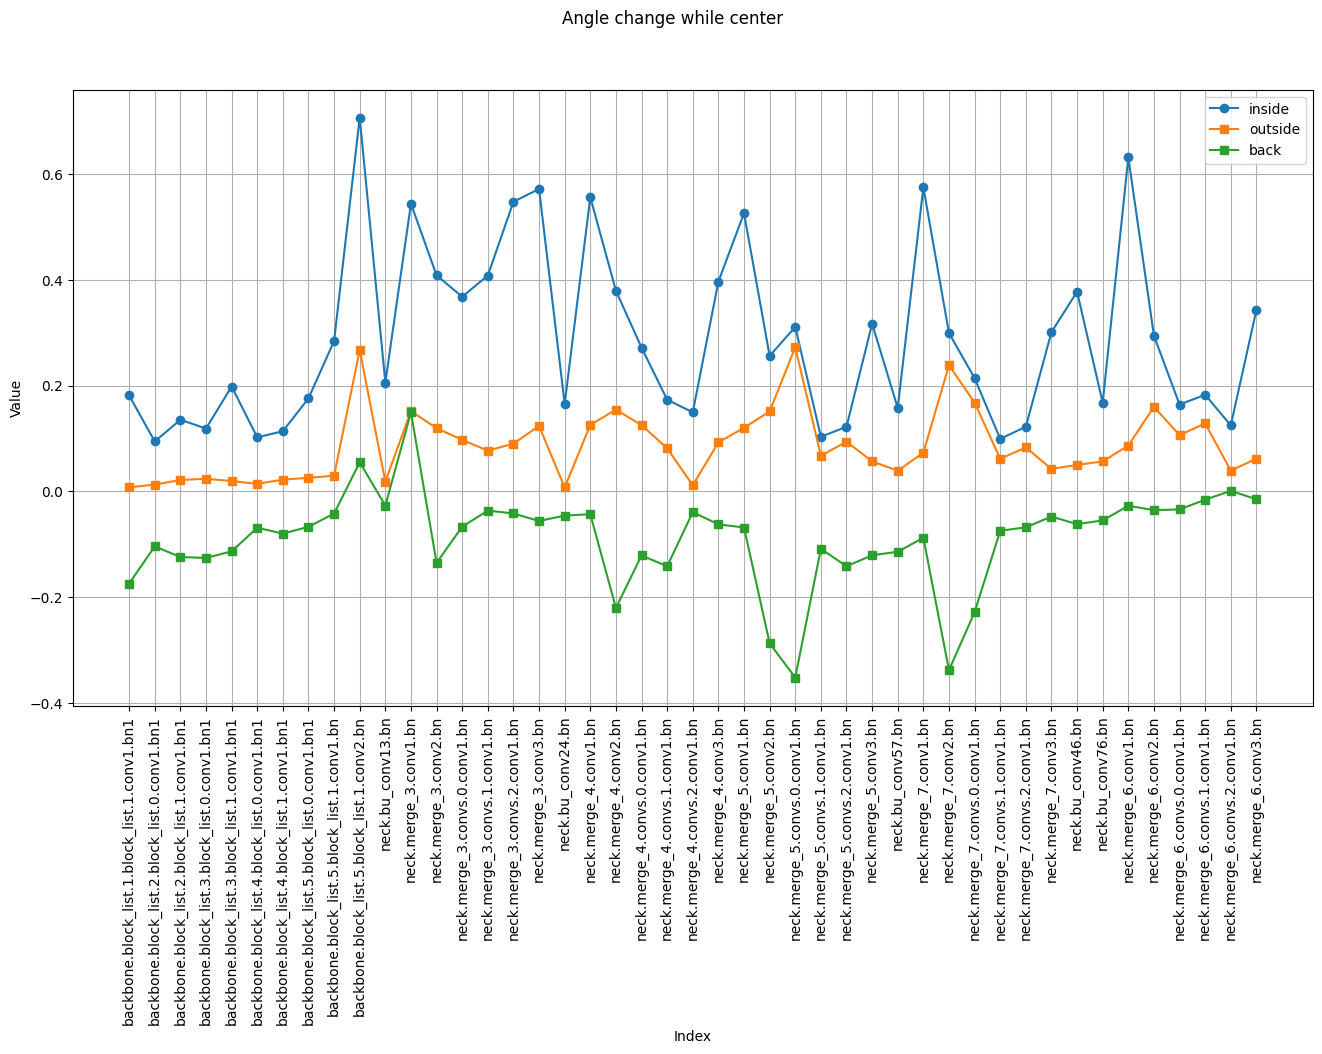

In [23]:
x = np.arange(3, len(before_conv) + 1)

plt.figure(figsize=(16, 8))

# _np[:, 2]
plt.plot(x, inside, marker='o', label='inside', linestyle='-')
plt.plot(x, outside,  marker='s', label='outside', linestyle='-')
plt.plot(x, back,  marker='s', label='back', linestyle='-')

# plt.xticks(x, [str(i) for i in x], rotation=90)
plt.xticks(x, [bns_fwd_names[i - 1] for i in x], rotation=90)

# plt.axvline(x=30.5, color='black', linestyle='--')

# plt.text(10, 0.8, 'Backbone', ha='right', fontsize=12)
# plt.text(40, 0.8, 'Neck', ha='left', fontsize=12)

plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.suptitle("Angle change while center")
# if savefig: plt.savefig("18.10. Изменение углов по всей модели при свёртке.png")
plt.show();


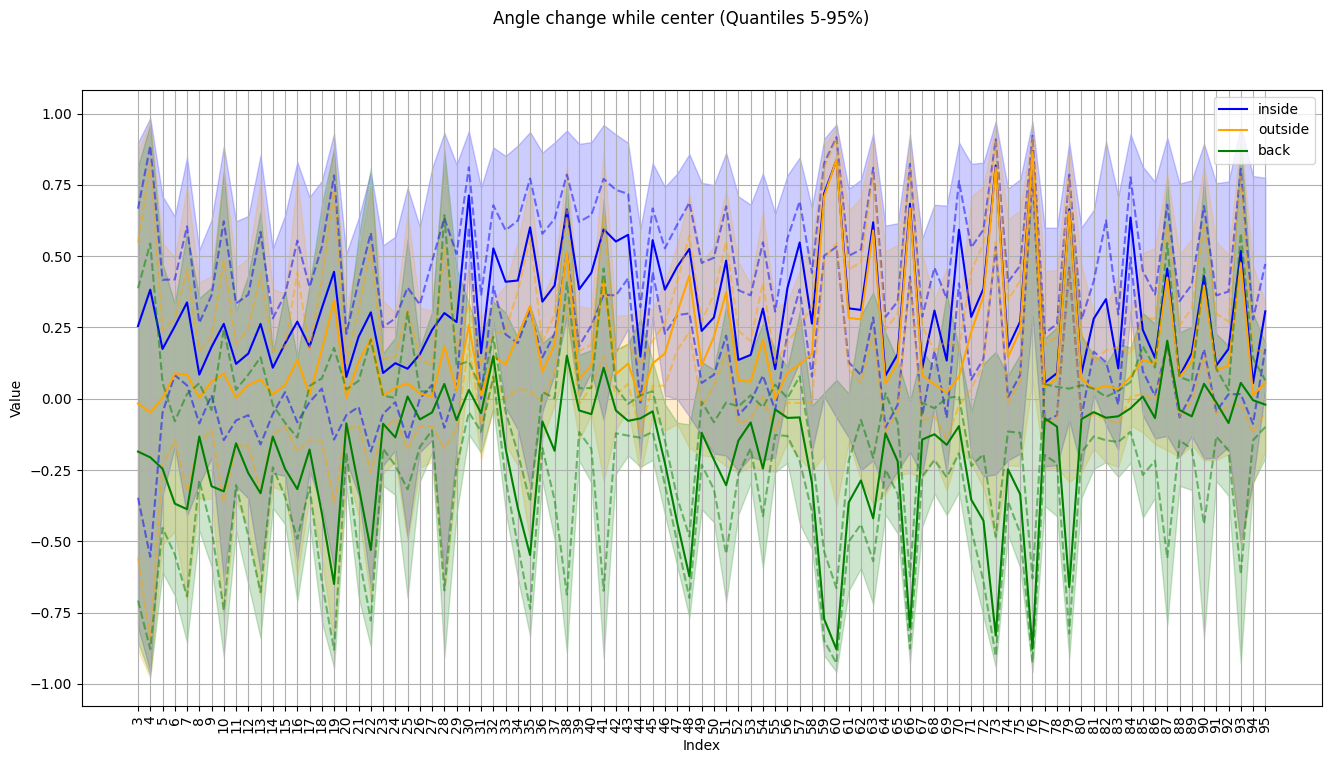

In [67]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(3, len(before_conv) + 1)

# inside = torch.stack(inside).cpu().numpy()  # (95, 5)
# outside = torch.stack(outside).cpu().numpy()
# back = torch.stack(back).cpu().numpy()

plt.figure(figsize=(16, 8))

# Функция для отрисовки трубки + линий
def plot_with_quantiles(x, quantiles, label, color):
    q05 = quantiles[:, 0]
    q25 = quantiles[:, 1]
    q50 = quantiles[:, 2]
    q75 = quantiles[:, 3]
    q95 = quantiles[:, 4]
    
    # Трубка между 5% и 95%
    plt.fill_between(x, q05, q95, alpha=0.2, color=color)
    
    # Дополнительно 25%-75%
    plt.plot(x, q25, linestyle='--', color=color, alpha=0.5)
    plt.plot(x, q75, linestyle='--', color=color, alpha=0.5)

    # Основная линия медианы
    plt.plot(x, q50, label=label, color=color)

# Рисуем все 3 серии
plot_with_quantiles(x, inside_np, label='inside', color='blue')
plot_with_quantiles(x, outside_np, label='outside', color='orange')
plot_with_quantiles(x, back_np, label='back', color='green')

plt.xticks(x, [str(i) for i in x], rotation=90)

plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.suptitle("Angle change while center (Quantiles 5-95%)")
plt.show()
